<h1> Geometric Operations and Other Mathematical Tools</h1>


Estimated time needed: **40** minutes


<h2>Objectives</h2>


In the first part of the lab, you will apply geometric transformations to an image. This allows you to perform different operations like reshape translation, i.e. to shift, reshape and rotate the image. In the second part of the lab, you will learn how to apply some basic array and matrix operations to the image. 


<ul>
    <li><a href='#PT'> Geometric Operations  </a>
        <ul>
            <li>Scaling</li>
            <li>Translation</li>
            <li>Rotation</li>   
          </ul>
        <li><a href='#PT'>  Mathematical Operations   </a>
        <ul>
            <li>Array Operations  </li>
            <li>Matix Operations n</li> 
          </ul>


</ul>


----


Download the image for the lab:


In [ ]:
# Tải các file ảnh 
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/lenna.png -O lenna.png
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/baboon.png -O baboon.png
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/barbara.png -O barbara.png  

--2026-01-30 13:34:46--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/lenna.png
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 198.23.119.245
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|198.23.119.245|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 473831 (463K) [image/png]
Saving to: ‘lenna.png’

lenna.png           100%[===================>] 462.73K   148KB/s    in 3.1s    

2026-01-30 13:34:51 (148 KB/s) - ‘lenna.png’ saved [473831/473831]

--2026-01-30 13:34:51--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/baboon.png
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-course

We will be using the following imported functions in this lab:


In [ ]:
# Import các thư viện
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

First, let's define a helper function to plot two images side-by-side. You will not need to understand this code this moment, but this function will be used repeatedly in this tutorial to showcase the results. 


In [ ]:
# Định nghĩa hàm để vẽ 2 ảnh cạnh nhau cho dễ so sánh
def plot_image(image_1, image_2,title_1="Orignal",title_2="New Image"):
    # Tạo figure với kích thước 10x10 inch
    plt.figure(figsize=(10,10))
    # Tạo subplot đầu tiên (1 hàng, 2 cột, vị trí 1)
    plt.subplot(1, 2, 1)
    # Hiển thị ảnh 1 với colormap gray (cho ảnh xám)
    plt.imshow(image_1,cmap="gray")
    plt.title(title_1)
    # Tạo subplot thứ hai (1 hàng, 2 cột, vị trí 2)
    plt.subplot(1, 2, 2)
    # Hiển thị ảnh 2 với colormap gray
    plt.imshow(image_2,cmap="gray")
    plt.title(title_2)
    plt.show()

#  Geometric Transformations


 Geometric transformations allow you to perform different operations like translation, i.e. to shift, reshape and rotate the image.


We can resize an image using the method  <code>resize()</code> of <code>PIL</code> images, which takes the resized image's <code>width</code> and <code>height</code> as paramters. 

Consider the following image:


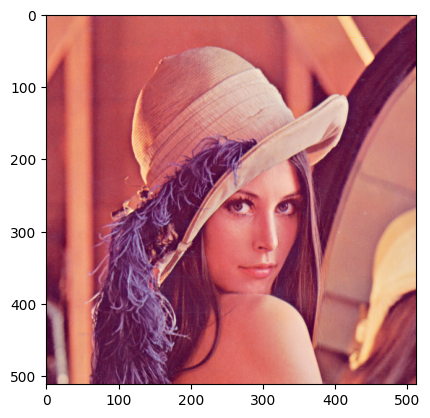

In [ ]:
image = Image.open("lenna.png")
plt.imshow(image)
plt.show()

We can scale the horizontal axis by two and leave the vertical axis as is:


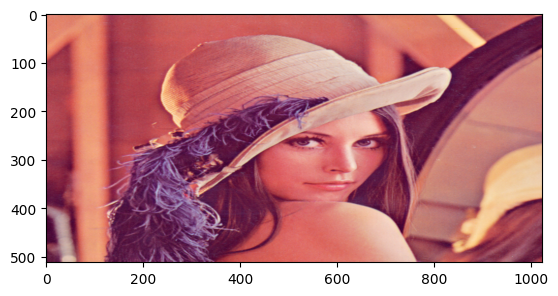

In [ ]:
# Lấy kích thước ảnh gốc
width, height = image.size
# PHÓNG ẢNH THEO CHIỀU NGANG (2 lần chiều rộng, giữ nguyên chiều cao)
new_width = 2 * width
new_hight = height
# Thay đổi kích thước
new_image = image.resize((new_width, new_hight))
plt.imshow(new_image)
plt.show()

In the same manner, we can scale the vertical axis by two:


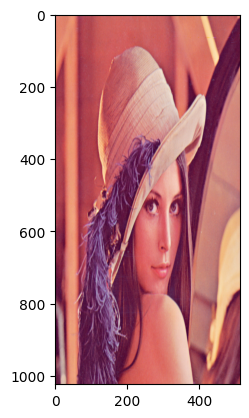

In [ ]:
new_width = width  # Giữ nguyên chiều rộng
new_hight = 2 * height # Chiều cao mới gấp đôi
new_image = image.resize((new_width, new_hight))# Thay đổi kích thước
plt.imshow(new_image)
plt.show()

We can double both the width and the height of the image:


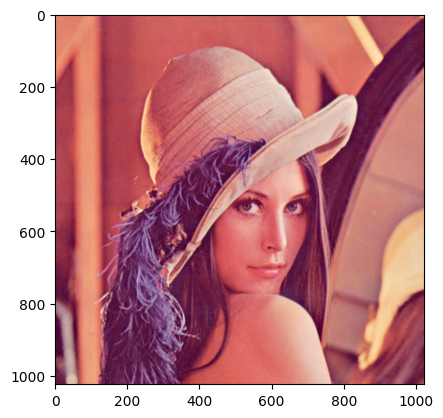

In [ ]:
# PHÓNG ĐỀU CẢ 2 CHIỀU (2 lần cả chiều rộng và chiều cao)
new_width = 2 * width  # Chiều rộng mới gấp đôi
new_hight = 2 * height # Chiều cao mới gấp đôi

new_image = image.resize((new_width, new_hight))   # Thay đổi kích thước

plt.imshow(new_image)
plt.show()

We can also shrink the image's width and height both by 1/2:


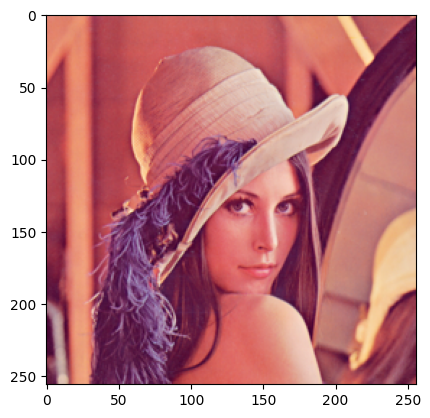

In [ ]:
# THU NHỎ ẢNH (1/2 kích thước gốc)
new_width = width // 2  # Chiều rộng mới bằng nửa chiều rộng gốc
new_hight = height // 2 # Chiều cao mới bằng nửa chiều cao gốc

new_image = image.resize((new_width, new_hight)) # Thay đổi kích thước
plt.imshow(new_image)
plt.show()

## Rotation 


We can rotate an image by angle $\theta$, using the method `rotate`.


We can rotate our toy image by 45 degrees:


In [ ]:
# XOAY ẢNH 45 ĐỘ
# Góc xoay 45 độ
theta = 45
# Xoay ảnh
new_image = image.rotate(theta)

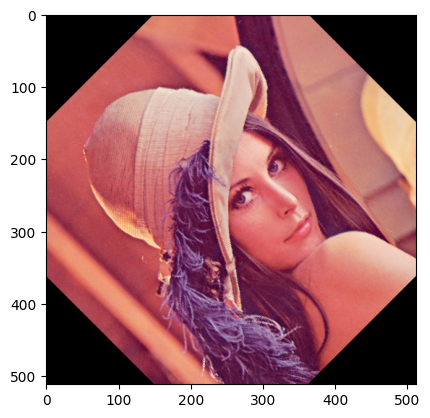

In [10]:
plt.imshow(new_image)
plt.show()

# Mathematical Operations 


## Array Operations 


We can perform array operations on an image; Using Python broadcasting, we can add a constant to each pixel's intensity value. 

Before doing that, we must first we convert the PIL image to a numpy array.


In [ ]:
# Chuyển đổi từ đối tượng PIL Image sang mảng NumPy
image = np.array(image)

We can then add the constant to the image array:


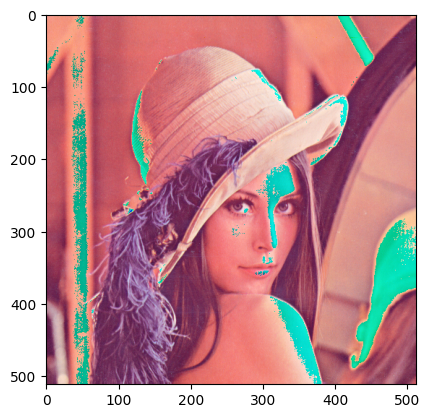

In [ ]:
# TĂNG ĐỘ SÁNG bằng cách cộng hằng số
new_image = image + 20 # Cộng thêm 20 vào mỗi giá trị pixel
# Hiển thị ảnh (tự động chuẩn hóa giá trị pixel)
plt.imshow(new_image)
plt.show()

We can also multiply every pixel's intensity value by a constant value.


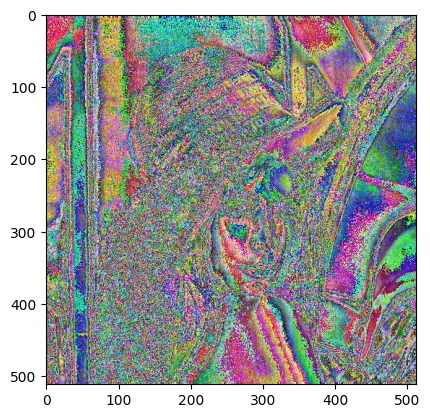

In [ ]:
# TĂNG ĐỘ SÁNG MẠNH bằng cách nhân hằng số
new_image = 10 * image # Nhân mỗi giá trị pixel với 10
plt.imshow(new_image)
plt.show()

We can add the elements of two arrays of equal shape. In this example, we generate an array of random noises with the same shape and data type as our image.


In [ ]:
# TẠO NHIỄU GAUSSIAN
# Tạo mảng nhiễu với phân phối chuẩn: mean=0, std=20, kích thước bằng ảnh
Noise = np.random.normal(0, 20, (height, width, 3)).astype(np.uint8)
Noise.shape # Kiểm tra kích thước của nhiễu (phải khớp với ảnh)

(512, 512, 3)

We add the generated noise to the image and plot the result. We see the values that have corrupted the image:


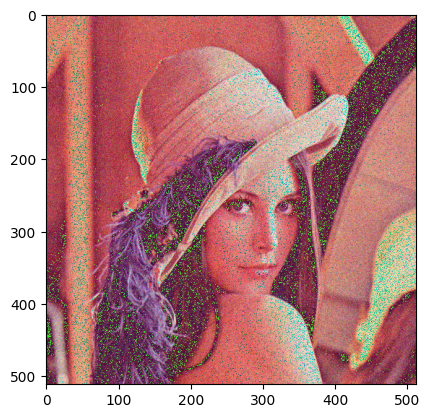

In [ ]:
# THÊM NHIỄU vào ảnh
 # Cộng nhiễu vào ảnh gốc
new_image = image + Noise

plt.imshow(new_image)
plt.show()

At the same time, we can multiply the elements of two arrays of equal shape. We can multiply the random image and the Lenna image and plot the result. 


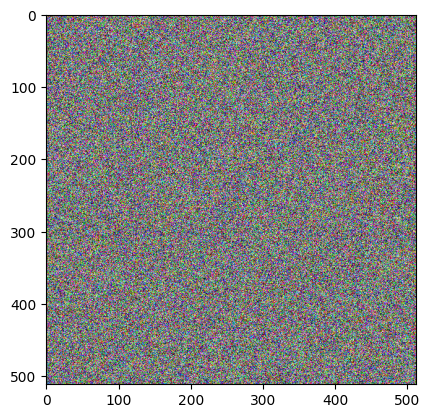

In [ ]:
# NHÂN ẢNH VỚI NHIỄU 
new_image = image*Noise

plt.imshow(new_image)
plt.show()

## Matrix Operations 


Grayscale images are matrices. Consider the following grayscale image:


In [ ]:

im_gray = Image.open("barbara.png")

Even though the image is gray, it has three channels; we can convert it to a one-channel image.


In [ ]:
# Import hàm grayscale từ PIL
from PIL import ImageOps 

In [ ]:
# CHUYỂN ẢNH MÀU SANG ẢNH XÁM
im_gray = ImageOps.grayscale(im_gray) 

We can convert the PIL image to a numpy array:


In [ ]:
# CHUYỂN ẢNH PIL SANG NUMPY ARRAY
im_gray = np.array(im_gray )

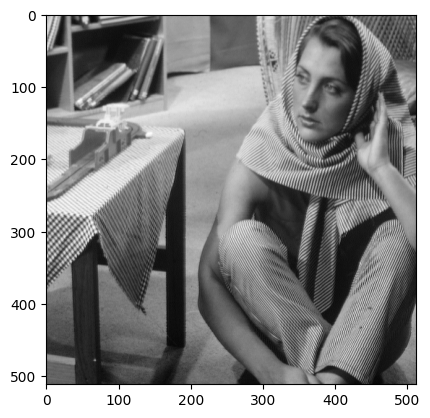

In [21]:
plt.imshow(im_gray,cmap='gray')
plt.show()

We can apply algorithms designed for matrices.  We can use  Singular Value Decomposition, decomposing our image matrix into  a product of three matrices.


In [ ]:
# PHÂN TÍCH SVD (SINGULAR VALUE DECOMPOSITION)
# Phân tách ma trận ảnh xám thành 3 ma trận: U, s, V
U, s, V = np.linalg.svd(im_gray , full_matrices=True)
# U: ma trận singular vectors trái 
# s: mảng các singular values 
# V: ma trận singular vectors phải 

We see <code>s</code> is not rectangular:


In [ ]:
# Kiểm tra kích thước của mảng
s.shape

(512,)

We can convert  <code>s</code> to a diagonal matrix <code>S</code>:


In [ ]:
# TẠO MA TRẬN ĐƯỜNG CHÉO S TỪ MẢNG s
S = np.zeros((im_gray.shape[0], im_gray.shape[1]))
# Đặt các giá trị đường chéo từ mảng s
# LƯU Ý: Có lỗi ở đây! Nên là im_gray.shape[0] thay vì image.shape[0]
S[:image.shape[0], :image.shape[0]] = np.diag(s)

We can plot the matrix U and V:


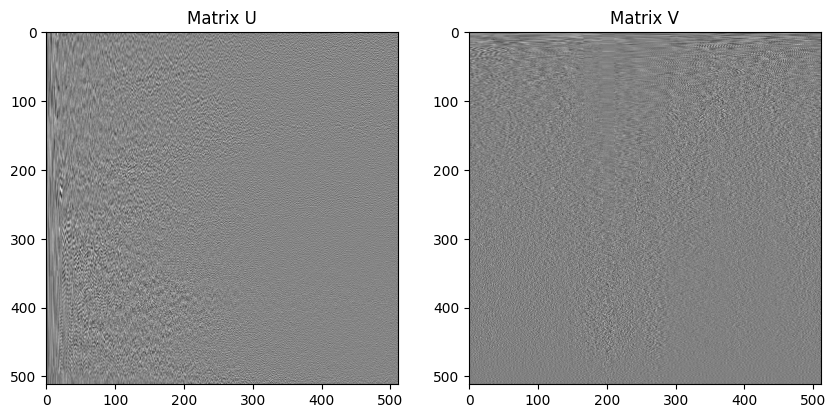

In [ ]:
# VẼ MA TRẬN U VÀ V (có thể không hiển thị tốt vì U, V là ma trận số thực)
plot_image(U, V, title_1="Matrix U", title_2="Matrix V")

We see most of the elements in S are zero:


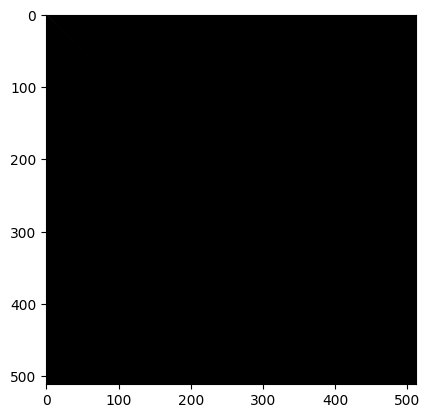

In [26]:
plt.imshow(S, cmap='gray')
plt.show()

We can find the matrix product of all the  matrices. First, we can perform matrix multiplication on S and U and assign it to `B` and plot the results: 


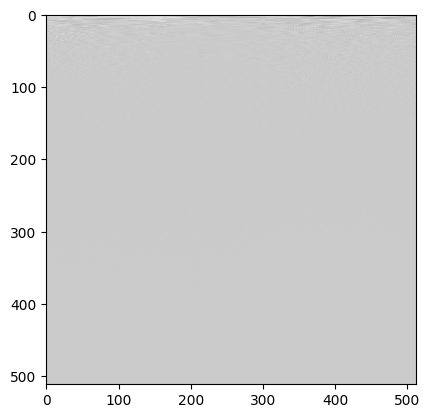

In [ ]:
# TÁI TẠO ẢNH TỪ CÁC THÀNH PHẦN SVD
# nhân ma trận, dot product của S và V
B = S.dot(V)
plt.imshow(B,cmap='gray')
plt.show()

We can find the matrix product of `U`, `S`, and `B`. We see it's the entire image:


In [ ]:
A = U.dot(B)# dot product của U và B

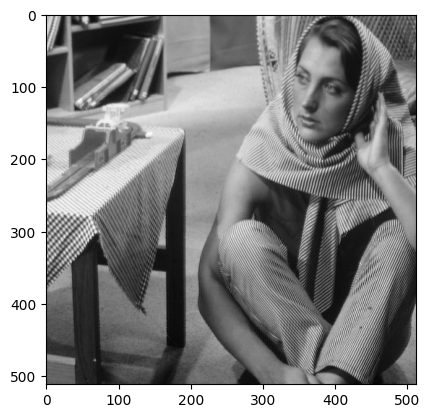

In [29]:
plt.imshow(A,cmap='gray')
plt.show()

It turns out that many elements are redundant. We can eliminate some rows and columns of S and V and approximate the image by finding the product:


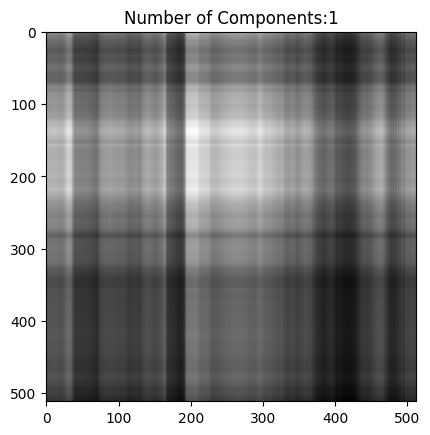

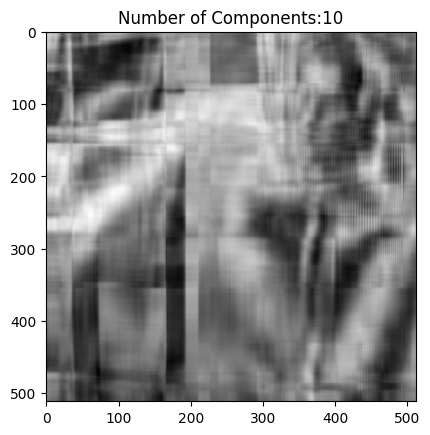

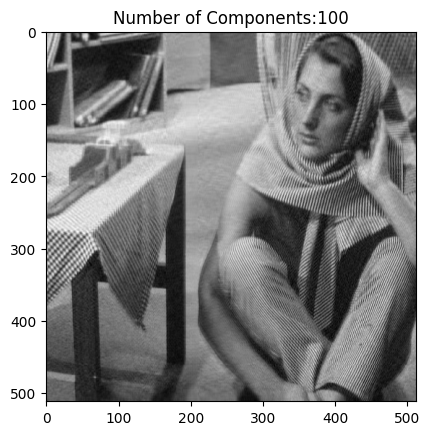

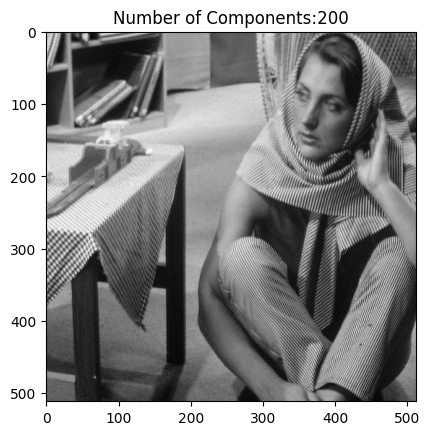

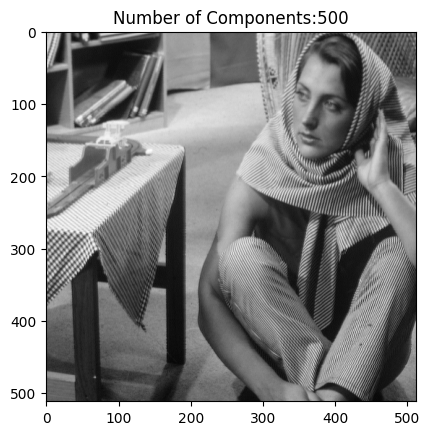

In [ ]:
# NÉN ẢNH BẰNG SVD - Chỉ giữ lại một số thành phần chính
# Thử nghiệm với số lượng singular values khác nhau
for n_component in [1,10,100,200, 500]:
    # giữ lại n_component singular values đầu tiên
    S_new = S[:, :n_component]# giữ n_component cột đầu của S
    V_new = V[:n_component, :]# Chỉ giữ n_component hàng đầu của V
    # Tái tạo ảnh với số thành phần bị giới hạn
    # A ≈ U * S_reduced * V_reduced^T
    A = U.dot(S_new.dot(V_new))
    plt.imshow(A,cmap='gray')
    plt.title("Number of Components:"+str(n_component))
    plt.show()

We see we only need 100 to 200 Components to represent the image.


# References 


[1]  Images were taken from: https://homepages.cae.wisc.edu/~ece533/images/
    
[2]  <a href='https://pillow.readthedocs.io/en/stable/index.html'>Pillow Docs</a>

[3]  <a href='https://opencv.org/'>Open CV</a>

[4] Gonzalez, Rafael C., and Richard E. Woods. "Digital image processing." (2017).

[5 ] Jian, Wushuai, Xueyan Sun, and Shuqian Luo. "Computer-aided diagnosis of breast microcalcifications based on dual-tree complex wavelet transform." Biomedical engineering online 11.1 (2012): 1-12.


<!--<h2>Change Log</h2>-->


<!--<table>
    <tr>
        <th>Date (YYYY-MM-DD)</th>
        <th>Version</th>
        <th>Changed By</th>
        <th>Change Description</th>
    </tr>
    <tr>
        <td>2020-07-20</td>
        <td>0.2</td>
        <td>Azim</td>
        <td>Modified Multiple Areas</td>
    </tr>
    <tr>
        <td>2020-07-17</td>
        <td>0.1</td>
        <td>Azim</td>
        <td>Created Lab Template</td>
    </tr>
</table>
-->


<h3 align="center"> &#169; IBM Corporation. All rights reserved. <h3/>
